In [34]:
### q3 Feature Engineering and Regression pipeline

### q3-1 Data Feature Engineering
import pandas as pd
 
# Load the dataset
df = pd.read_csv("C:\\shivangee\\Assignment4\\data\\q3_retail_promotions.csv")


# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month-end feature
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 28 else 0)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


----------------------------------------------------------------------------------------------------------
Instead of giving the model only a date, we break it into smaller useful parts.
This improves prediction accuracy because the model can now learn:
“Sales increase on weekends”
or
“Month-end shopping is higher”
----------------------------------------------------------------------------------------------------------

In [35]:
### q3-2 Temporal Train-test split
# Sort by date
df = df.sort_values('transaction_date')

# split index
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]
print(f"Train set: {train_df.shape}, Test set: {test_df.shape}")

Train set: (960, 13), Test set: (240, 13)


--------------------------------------------------------------------------------------------
Time-based data has temporal dependencies
Random split causes data leakage (future influencing past)
Using chronological split ensures model predicts future from past
This mimics real-world forecasting scenarios
--------------------------------------------------------------------------------------------

In [36]:
### q3-3 Preprocessing and Regression Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define feature columns

y_train = train_df['items_sold']
y_test = test_df['items_sold']

#drop target and date columns
X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
X_test = test_df.drop(columns=['items_sold', 'transaction_date'])

# columns groups
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Preprocessing pipelines

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
    ]
)


Linear Regression Performance(mse): 735.8237886064817
Linear Regression Performance(mae): 21.053467426613114
Linear Regression Performance(r2): 0.787535754369351


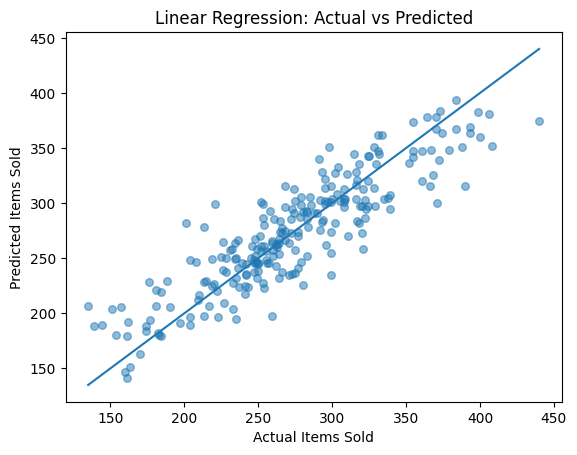

In [37]:
### q3-4 Model Training and Evaluation
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# (A) Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

# Metrics for Linear Regression
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance(mse):", mse_lr)
print("Linear Regression Performance(mae):", mae_lr)
print("Linear Regression Performance(r2):", r2_lr)

# Plotting predictions vs actuals for Linear Regression
plt.scatter(y_test, y_pred_lr, alpha=0.5,s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

--------------------------------------------------------------------------
MAE = 21

On average, prediction is off by around 21 items.
=======================================================================
R² = 0.78

The model explains about 78% of sales variation.

This is a strong result.
--------------------------------------------------------------------------

Random Forest Performance(mse): 1014.2912875
Random Forest Performance(mae): 25.058333333333334
Random Forest Performance(r2): 0.7071301083421797


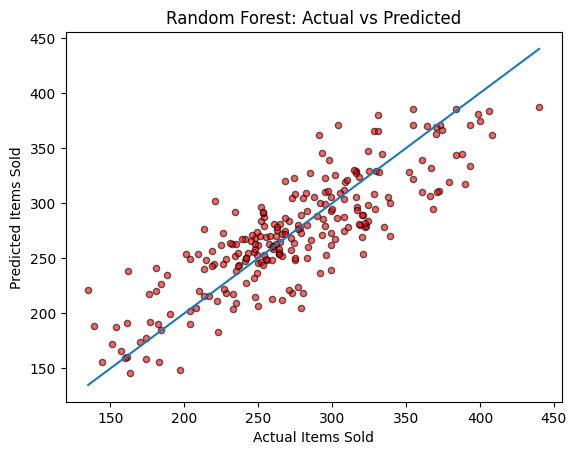

In [38]:
# (B) Random Forest Regressor Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics for Random Forest Regressor
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Performance(mse):", mse_rf)
print("Random Forest Performance(mae):", mae_rf)
print("Random Forest Performance(r2):", r2_rf)

# Plotting predictions vs actuals for Random Forest Regressor
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='red', edgecolor='k', s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

-------------------------------------------------------------------------------------
MAE = 25

Prediction error is around 25 items.
==================================================================================
R² = 0.70

The model explains about 70% of variation.

Good, but weaker than Linear Regression here.
-------------------------------------------------------------------------------------

In [39]:
# Feature importance from Random Forest

ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(encoded_cat_features)

# extract feature importances
importances = rf_pipeline.named_steps['model'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)
feature_importance_df.head(10)



,feature,importance
15,store_size_small,0.183992
2,is_festival,0.174403
13,location_type_urban,0.140507
6,day_of_week,0.095901
0,store_id,0.063053
14,store_size_medium,0.058167
1,is_weekend,0.058036
3,competition_density,0.053348
5,month,0.040504
12,location_type_semi-urban,0.039014
